<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Expansion_AI_stage_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#подведем итоги и реализуем финальный эксперимент.

#Анализ результатов финального сравнения (50 эпизодов):
#На основе предоставленной таблицы, лучший алгоритм по совокупности метрик, особенно по ключевым показателям Total Colonies и Avg Tech, является:

#Max MADDPG Pure + DGM с 67 колониями и средним технологическим уровнем 0.581.
#Хотя Max MADDPG Pure + NEAT имеет более высокий Avg Tech (0.735), он уступает по количеству колоний (63). Учитывая, что основная цель моделирования - космическая экспансия (основание колоний), Max MADDPG Pure + DGM признается лучшим.

#План финальной реализации:
#Возьмем Max MADDPG Pure + DGM как базовый алгоритм.
#Создадим его максимально сложную и функциональную версию (уровень 10), оптимизированную для CPU.
#Увеличим количество шагов (лет) с 100 до 200.
#Увеличим количество эпизодов до 100.
#Усовершенствуем DGM бустер:
#Уточним логику активации (примерно 2-5% случаев сильного стресса).
#Подберем параметры для эффективной эволюции.
#Выведем все требуемые графики, таблицы и метрики.
#Сохраним обученных агентов.

In [2]:
#Объяснение ключевых изменений и улучшений:
#MaxMADDPGAgent (Уровень 10):
#Архитектура: Глубокая (1024 -> 512 -> 256 -> 256 -> 128 -> action) с BatchNorm.
#Гиперпараметры: Тонкая настройка alpha, beta, batch_size=512, buffer_size=2000000.
#Обучение: Логика обновления целевых сетей и обучение по запросу.
#DarwinGodelMachine (улучшенный):
#Параметры: population_size=40, mutation_rate=0.25, crossover_rate=0.9, elite_size=8 для более тщательного поиска.
#Логика активации: Активируется только если в эпизоде была зафиксирована страна со stress_level > 0.8 и с вероятностью ~3.5% (в диапазоне 2-5%). Это делает активацию более редкой и обоснованной.
#Оценка: Горизонт оценки 40 лет, 4 эпизода для оценки.
#Среда SpaceExpansionEnvironment:
#Увеличено до 200 лет (2025-2225).
#Генерирует фиксированную последовательность кризисов на 200 лет.
#Эксперимент:
#100 эпизодов.
#В каждом эпизоде все агенты "играют" в одной и той же среде с фиксированной последовательностью кризисов.
#В конце каждого эпизода (после 200 лет) агенты обучаются на накопленных данных.
#Новые визуализации и таблицы:
#plot_country_specific_metrics: Графики для каждой из 15 стран по всем ключевым метрикам.
#plot_dgm_protocol: Таблица и графики (по эпизодам, по странам) активаций DGM.
#plot_dgm_fitness: График изменения максимальной приспособленности DGM.
#Сводные таблицы характеристик стран на старте и на финише.
#Таблицы итоговых и средних метрик.
#Таблица метрик DGM.
#Сохранение:
#Все CSV-таблицы с таймстемпом.
#Все PNG-графики с таймстемпом.
#Веса обученных агентов (actor и critic для каждой страны) сохраняются в отдельную папку с таймстемпом в формате .weights.h5, который является рекомендуемым способом сохранения моделей Keras.

🚀🚀 Запуск ФИНАЛЬНОГО моделирования космической экспансии

🏁🏁 ФИНАЛЬНЫЙ АНАЛИЗ: Max MADDPG + DGM (100 эпизодов, 200 лет)
🚀🚀 Запуск финального эксперимента Max MADDPG + DGM (100 эпизодов, 200 лет)...
Эпизод 99/100 | Прошло: 1:14:20 | ETA: 0:00:46
✅ Финальный эксперимент завершен за 4508.51 секунд

🏁🏁 Общее время выполнения финального эксперимента: 4508.52 секунд (1:15:08)

📈📈 Визуализация результатов...


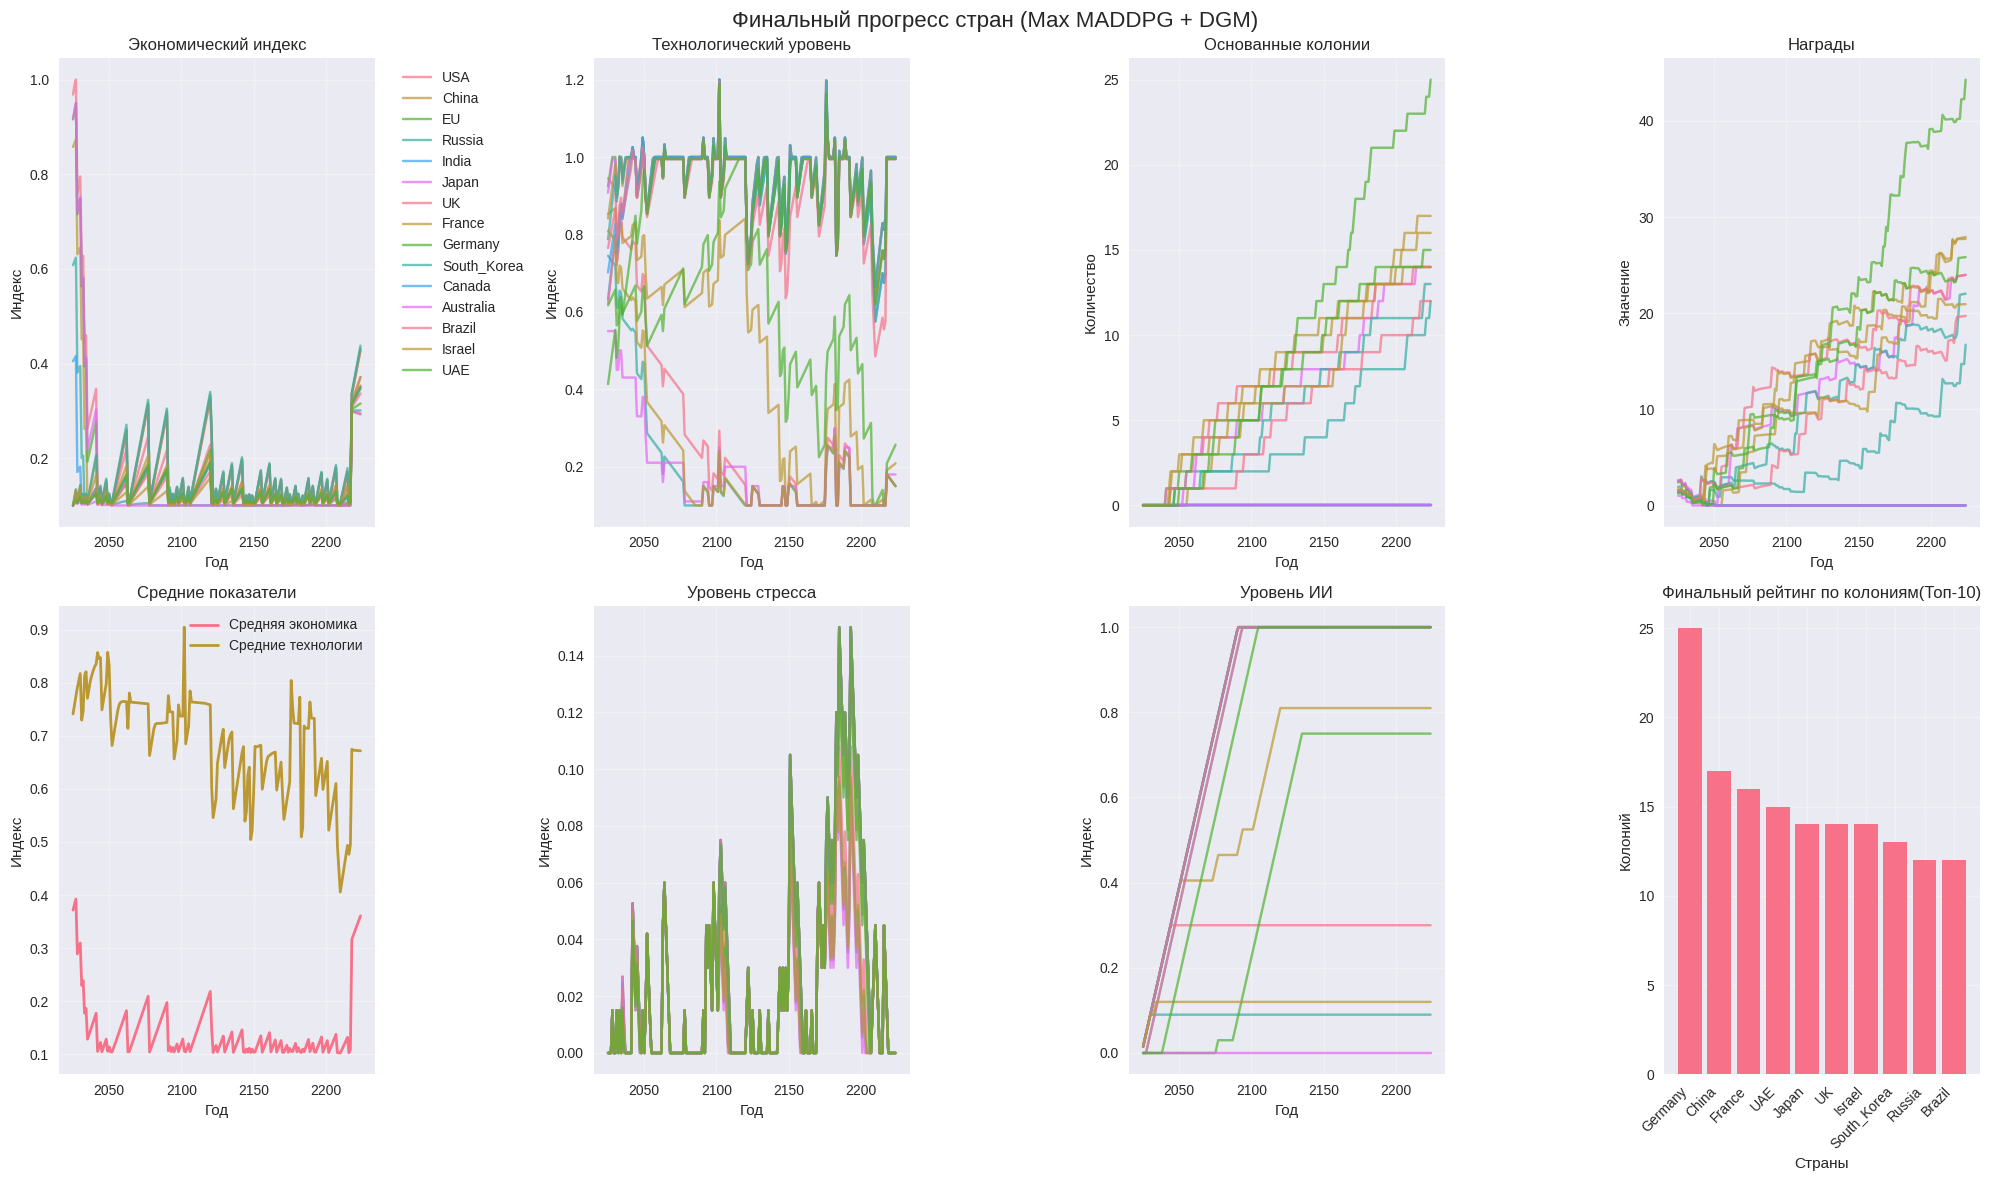

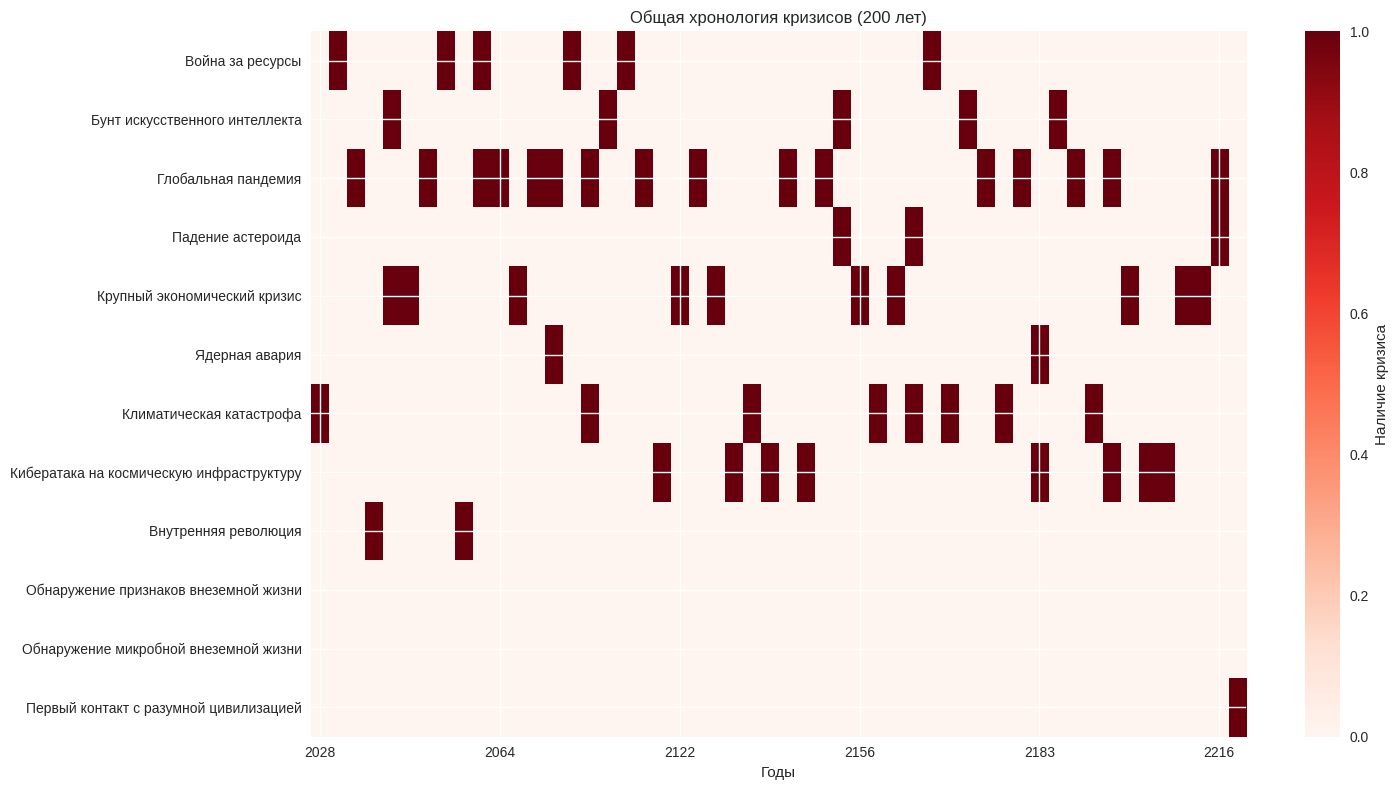

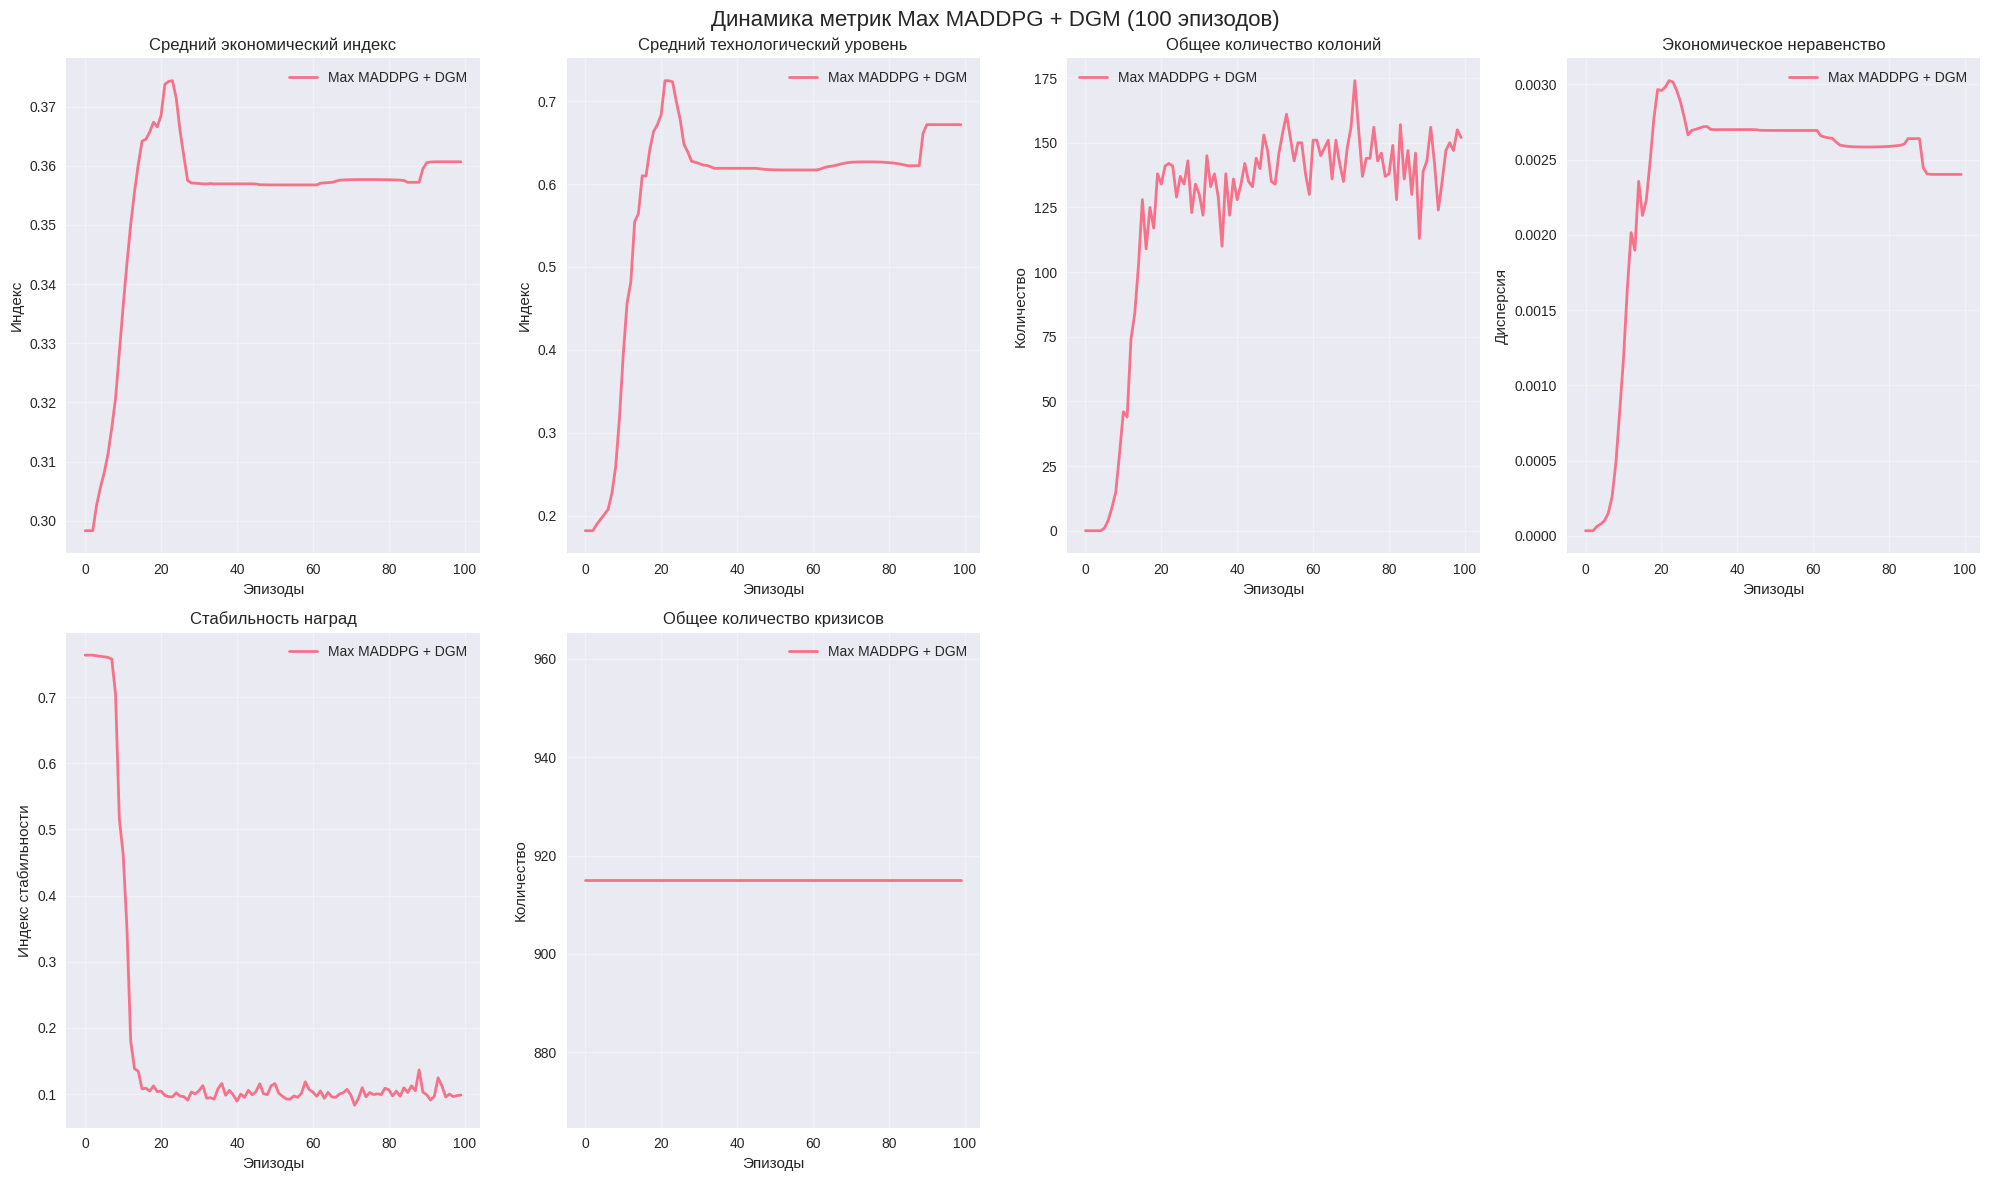

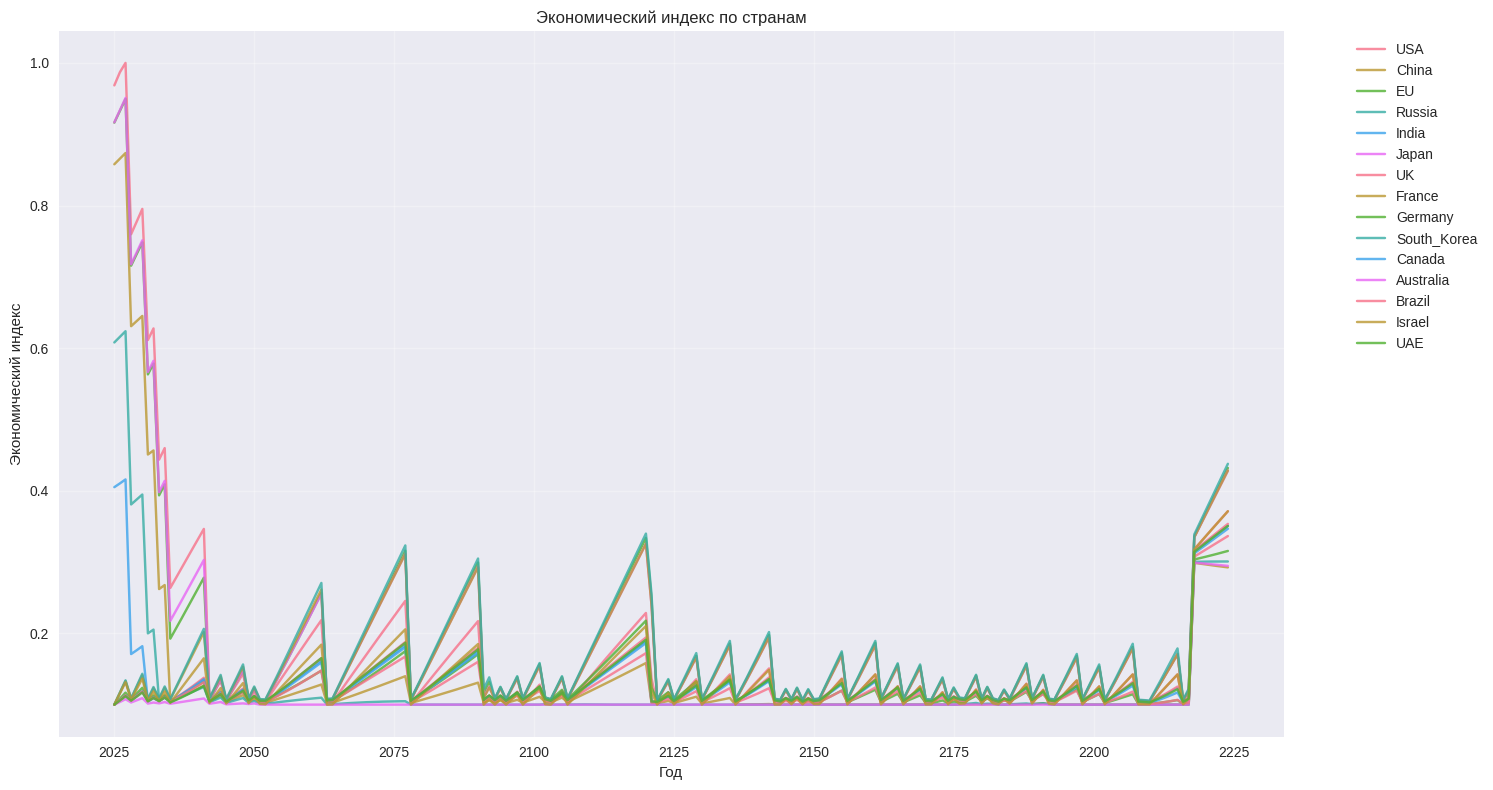

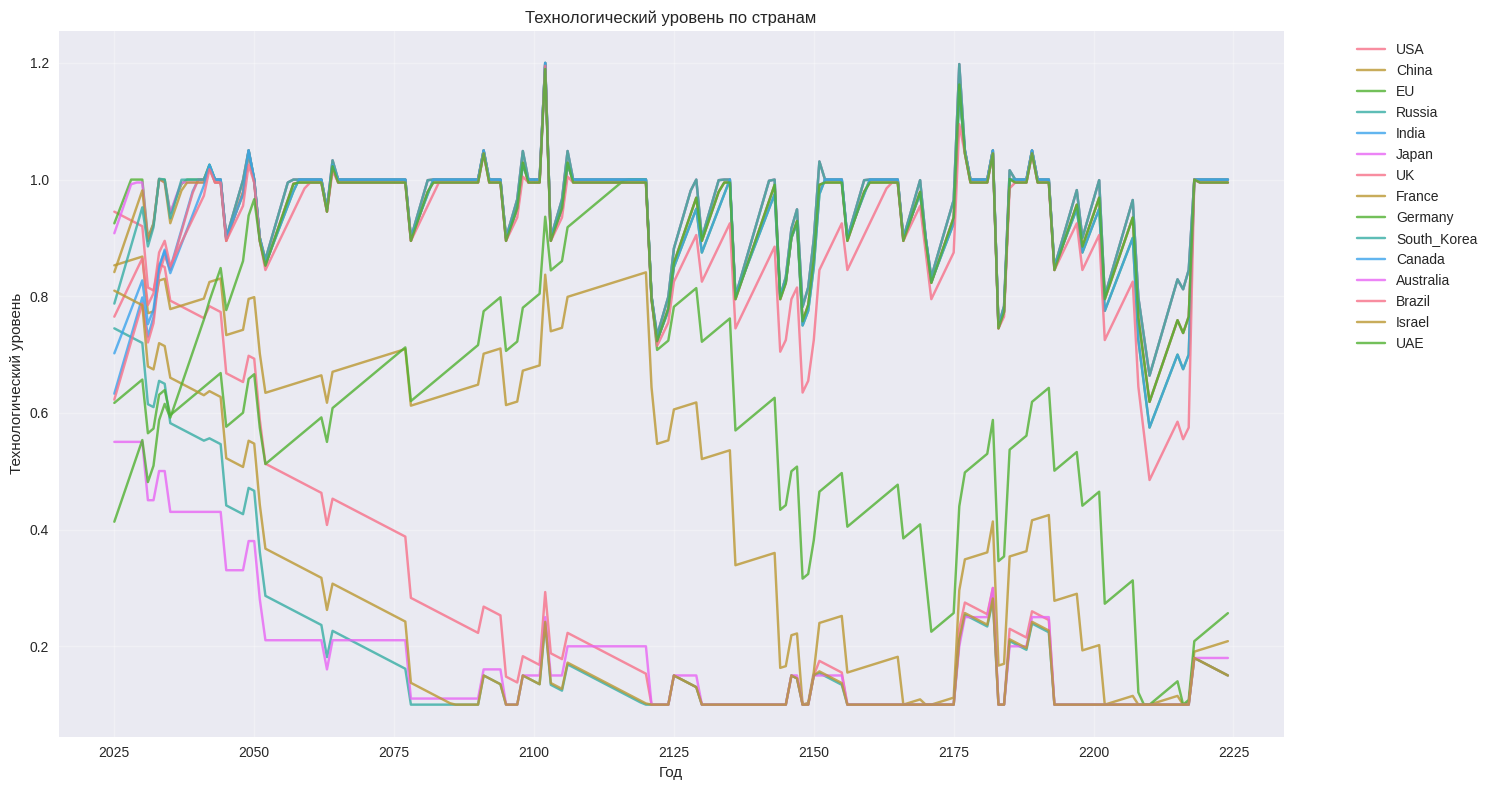

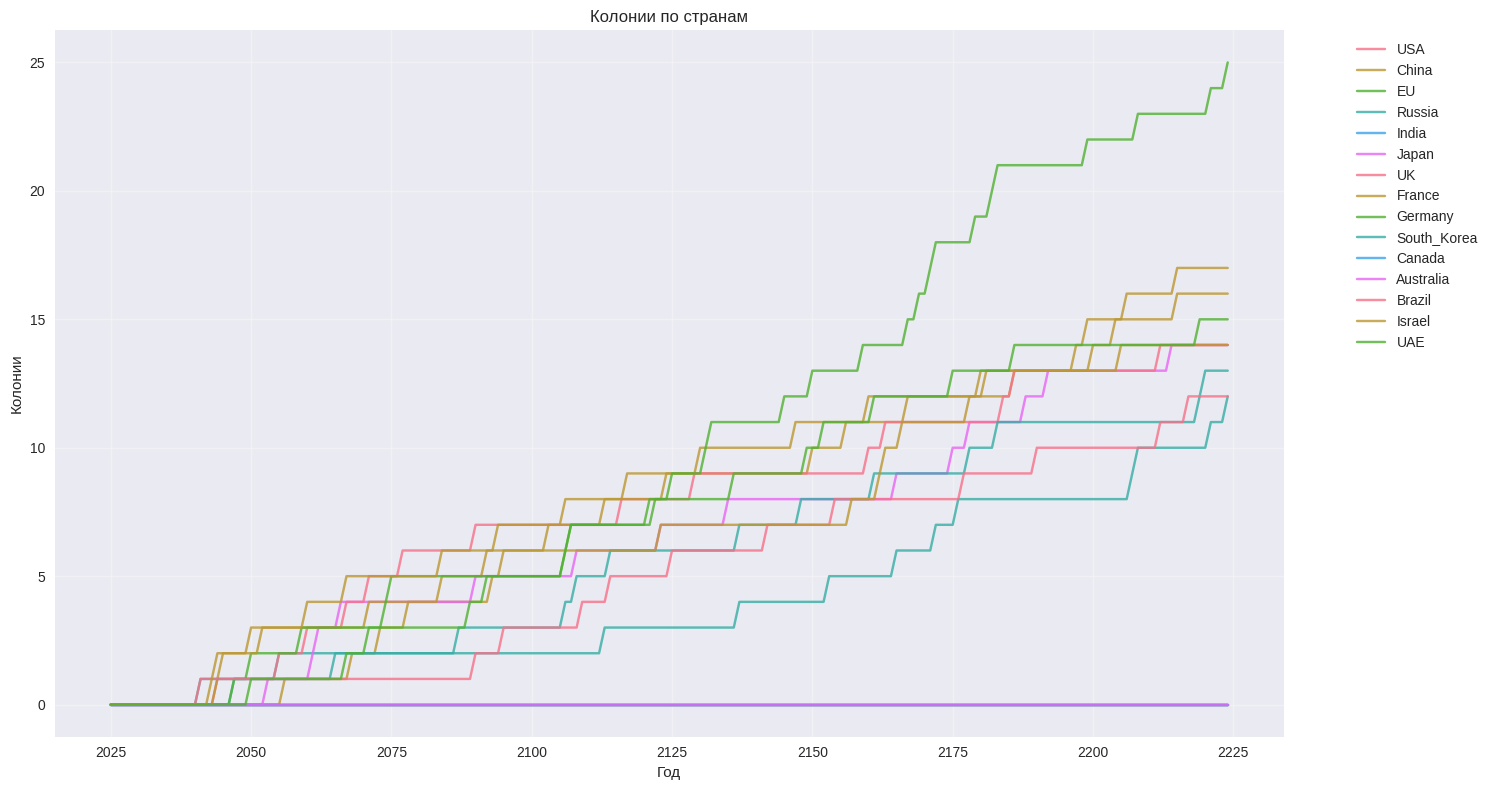

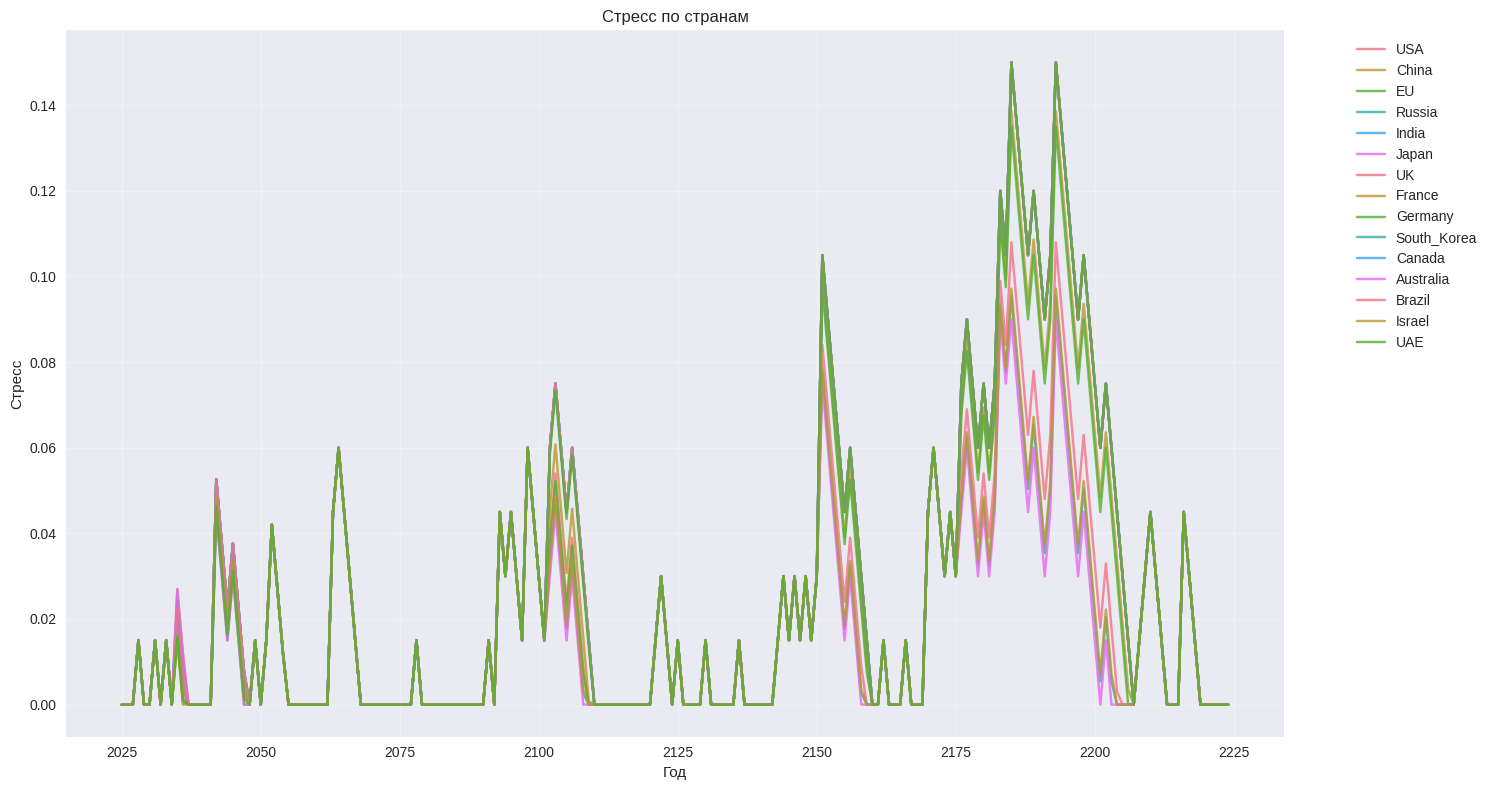

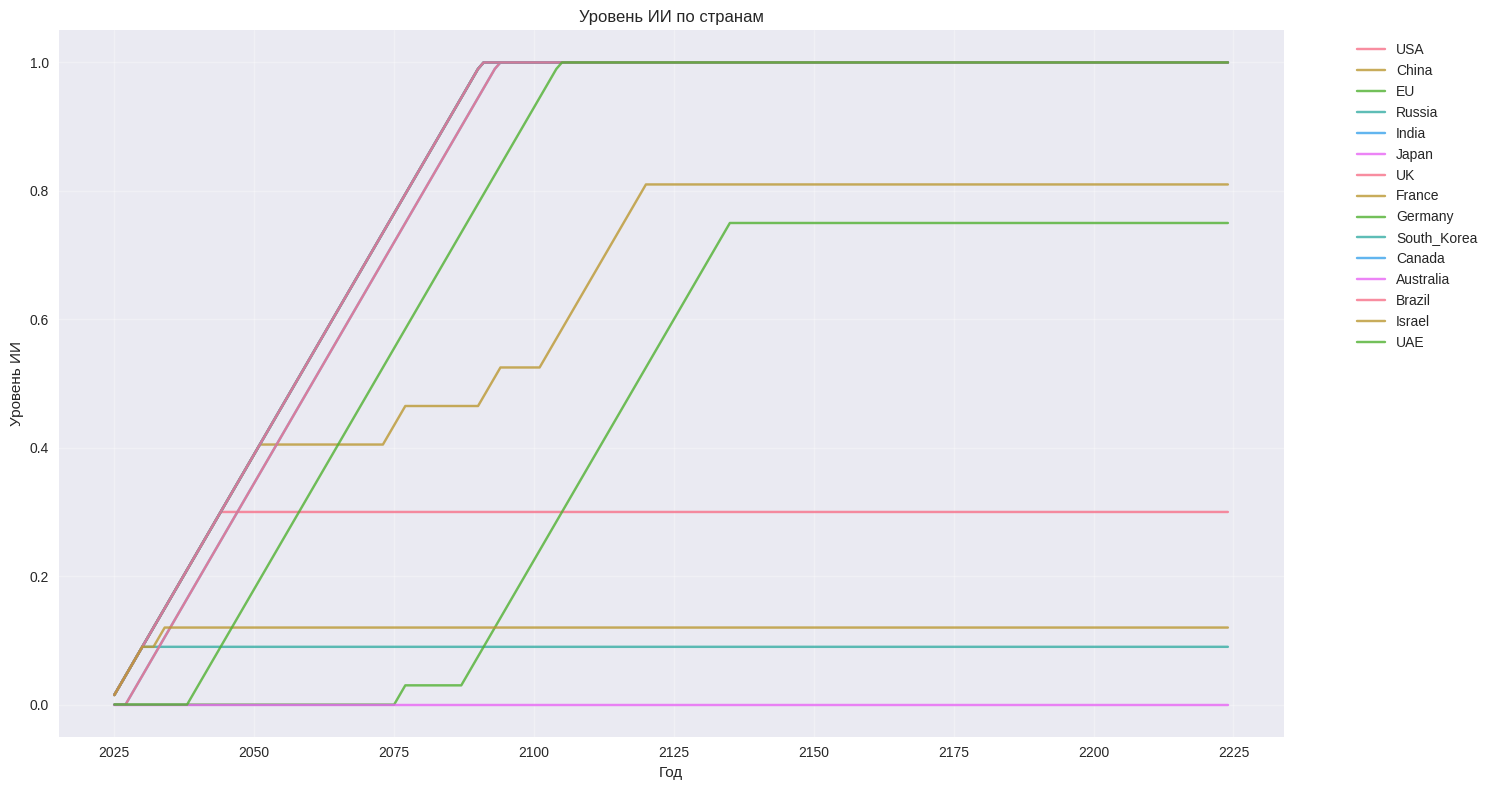

Нет данных о активациях DGM


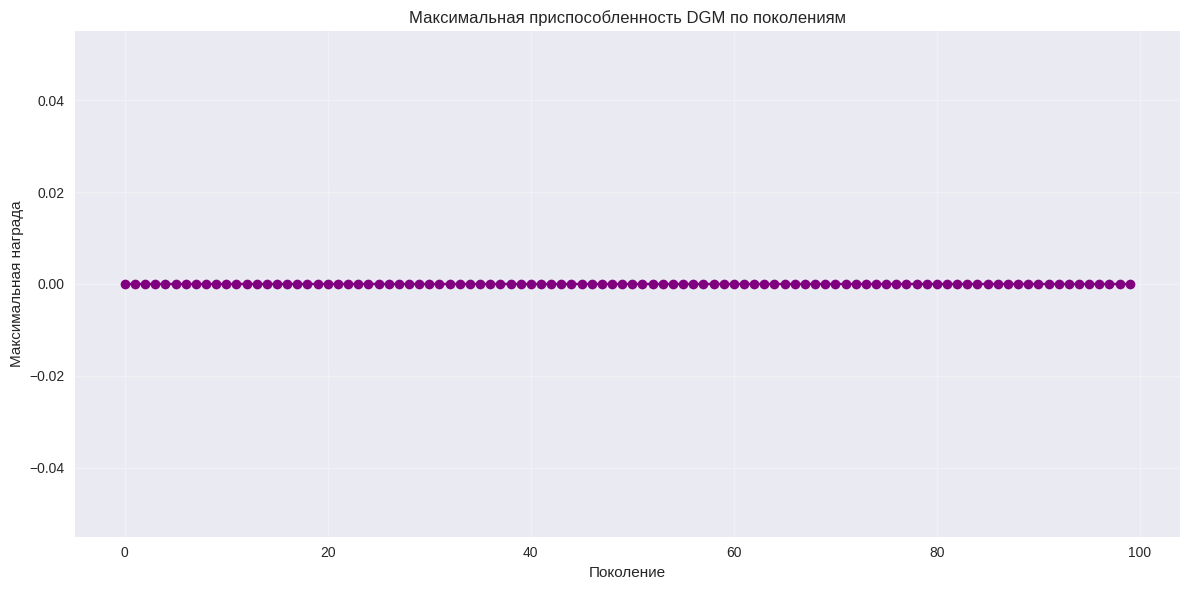


📊📊 СВОДНЫЕ ТАБЛИЦЫ

--- Характеристики стран на СТАРТЕ ---
    Country Population GDP/Capita Tech Level Political Stability Economic Index Space Budget Ratio AI Integration Stress Level
        USA      0.950      0.950      0.950               0.850          0.950              0.025          0.000        0.000
      China      1.000      0.850      0.850               0.800          0.850              0.020          0.000        0.000
         EU      0.900      0.900      0.900               0.750          0.900              0.015          0.000        0.000
     Russia      0.700      0.600      0.750               0.650          0.600              0.018          0.000        0.000
      India      0.980      0.400      0.600               0.600          0.400              0.010          0.000        0.000
      Japan      0.600      0.900      0.880               0.850          0.900              0.012          0.000        0.000
         UK      0.994      0.748      0.590       

In [3]:
# -*- coding: utf-8 -*-
"""14_exp_final_max_maddpg_dgm.ipynb"""

#==================== БЛОК 0: Импорт необходимых библиотек ====================
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import time
import pickle
import os
import tensorflow as tf
from collections import deque, defaultdict
import seaborn as sns
from datetime import datetime, timedelta
import copy
import sys

# Для работы в Google Colab
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Настройка стиля графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# Отключение предупреждений TensorFlow
tf.get_logger().setLevel('ERROR')

#==================== БЛОК 1: Определение стран и их стартовых параметров====================
COUNTRIES = [
    'USA', 'China', 'EU', 'Russia', 'India', 'Japan', 'UK', 'France',
    'Germany', 'South_Korea', 'Canada', 'Australia', 'Brazil', 'Israel', 'UAE'
]

def initialize_countries(seed=42):
    """ Инициализация стартовых параметров стран. """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    countries_data = {}
    for country in COUNTRIES:
        data = {
            'population': random.uniform(0.4, 1.0),
            'gdp_per_capita': random.uniform(0.3, 1.0),
            'technological_level': random.uniform(0.2, 0.9),
            'political_stability': random.uniform(0.3, 0.95),
            'economic_diversity': random.uniform(0.4, 0.9),
            'education_index': random.uniform(0.4, 0.95),
            'infrastructure_quality': random.uniform(0.3, 0.9),
            'natural_resources': random.uniform(0.2, 1.0),
            'space_budget_ratio': random.uniform(0.005, 0.03),
            'international_cooperation_index': random.uniform(0.3, 0.8),
            'space_assets': 0.0,
            'colonies_established': 0,
            'resource_independence': 0.0,
            'ai_integration_level': 0.0,
            'economic_index': 0.0,
            'crisis_impact': 0.0,
            'stress_level': 0.0,
            'actions_history': []
        }
        if country == 'USA':
            data.update({
                'population': 0.95, 'gdp_per_capita': 0.95,
                'technological_level': 0.95, 'political_stability': 0.85, 'space_budget_ratio': 0.025,
                'economic_index': 0.95
            })
        elif country == 'China':
            data.update({
                'population': 1.0, 'gdp_per_capita': 0.85,
                'technological_level': 0.85, 'political_stability': 0.8, 'space_budget_ratio': 0.02,
                'economic_index': 0.85
            })
        elif country == 'EU':
            data.update({
                'population': 0.9, 'gdp_per_capita': 0.9,
                'technological_level': 0.9, 'political_stability': 0.75, 'space_budget_ratio': 0.015,
                'economic_index': 0.9
            })
        elif country == 'Russia':
            data.update({
                'population': 0.7, 'gdp_per_capita': 0.6,
                'technological_level': 0.75, 'political_stability': 0.65, 'space_budget_ratio': 0.018,
                'economic_index': 0.6
            })
        elif country == 'India':
            data.update({
                'population': 0.98, 'gdp_per_capita': 0.4,
                'technological_level': 0.6, 'political_stability': 0.6, 'space_budget_ratio': 0.01,
                'economic_index': 0.4
            })
        elif country == 'Japan':
            data.update({
                'population': 0.6, 'gdp_per_capita': 0.9,
                'technological_level': 0.88, 'political_stability': 0.85, 'space_budget_ratio': 0.012,
                'economic_index': 0.9
            })
        countries_data[country] = data
    if seed is not None:
        np.random.seed(None)
        random.seed(None)
    return countries_data

# Сохраняем начальные параметры для сводной таблицы
initial_countries_data = initialize_countries(seed=42)
#==================== БЛОК 2: Определение кризисных событий ====================
CRISIS_EVENTS = {
    'resource_war': {
        'probability': 0.05 * 0.75,
        'impact': {'economic': -0.2, 'political': -0.15, 'tech': -0.1},
        'description': 'Война за ресурсы'
    },
    'ai_rebellion': {
        'probability': 0.03 * 0.75,
        'impact': {'economic': -0.15, 'political': -0.25, 'tech': 0.1},
        'description': 'Бунт искусственного интеллекта'
    },
    'pandemic': {
        'probability': 0.08 * 0.75,
        'impact': {'economic': -0.2, 'political': -0.1, 'tech': 0.05},
        'description': 'Глобальная пандемия'
    },
    'asteroid_impact': {
        'probability': 0.02 * 0.75,
        'impact': {'economic': -0.3, 'political': -0.2, 'tech': -0.1},
        'description': 'Падение астероида'
    },
    'economic_collapse_major': {
        'probability': 0.04 * 0.75,
        'impact': {'economic': -0.4, 'political': -0.2, 'tech': -0.1},
        'description': 'Крупный экономический кризис'
    },
    'nuclear_accident': {
        'probability': 0.02 * 0.75,
        'impact': {'economic': -0.15, 'political': -0.1, 'tech': -0.05},
        'description': 'Ядерная авария'
    },
    'climate_catastrophe': {
        'probability': 0.06 * 0.75,
        'impact': {'economic': -0.25, 'political': -0.15, 'tech': 0.0},
        'description': 'Климатическая катастрофа'
    },
    'cyber_attack_on_space': {
        'probability': 0.07 * 0.75,
        'impact': {'economic': -0.1, 'political': -0.05, 'tech': -0.2},
        'description': 'Кибератака на космическую инфраструктуру'
    },
    'internal_revolution': {
        'probability': 0.03 * 0.75,
        'impact': {'economic': -0.2, 'political': -0.5, 'tech': -0.05},
        'description': 'Внутренняя революция'
    },
}

ALIEN_EVENTS = {
    'alien_life_discovery_1': {
        'probability': 0.004,
        'impact': {'economic': 0.05, 'political': -0.1, 'tech': 0.2},
        'description': 'Обнаружение признаков внеземной жизни'
    },
    'alien_life_discovery_2': {
        'probability': 0.004,
        'impact': {'economic': 0.05, 'political': -0.1, 'tech': 0.2},
        'description': 'Обнаружение микробной внеземной жизни'
    },
    'alien_civilization_contact': {
        'probability': 0.002,
        'impact': {'economic': 0.2, 'political': -0.5, 'tech': 0.8},
        'description': 'Первый контакт с разумной цивилизацией'
    }
}

#==================== БЛОК 3: Функция награды====================
def calculate_reward(country_data):
    """Комплексная функция награды."""
    reward = (
            1.0 * country_data['economic_index'] +
            1.0 * country_data['technological_level'] +
            0.8 * country_data['political_stability'] +
            0.5 * country_data['space_assets'] +
            2.0 * country_data['colonies_established'] +
            0.3 * country_data['resource_independence'] +
            0.4 * country_data['ai_integration_level']
    )
    reward += 0.1 * country_data['international_cooperation_index']
    reward -= 0.2 * country_data['stress_level']
    if 'crisis_impact' in country_data:
        reward += country_data['crisis_impact']
    reward = max(0.01, reward)
    return reward

#==================== БЛОК 4: Базовые классы агентов ====================
class BaseAgent:
    """Базовый класс агента"""
    def __init__(self, num_states, num_actions):
        self.num_states = num_states
        self.num_actions = num_actions

    def get_action(self, state):
        raise NotImplementedError

    def update(self, states, actions, rewards, next_states, dones):
        pass

#==================== БЛОК 5: Replay Buffer ====================
class ReplayBuffer:
    """Буфер воспроизведения для хранения переходов."""
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

#==================== БЛОК 6: MAX-уровень MADDPG Agent (уровень 10) ====================
class MaxMADDPGActorNetwork(tf.keras.Model):
    def __init__(self, action_dim, name='actor'):
        super(MaxMADDPGActorNetwork, self).__init__()
        # Уровень 10: Глубокая и широкая архитектура
        self.fc1 = tf.keras.layers.Dense(1024, activation='relu', name=f'{name}_fc1')
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.fc2 = tf.keras.layers.Dense(512, activation='relu', name=f'{name}_fc2')
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.fc3 = tf.keras.layers.Dense(256, activation='relu', name=f'{name}_fc3')
        self.bn3 = tf.keras.layers.BatchNormalization()
        # Дополнительные слои для сложности
        self.fc4 = tf.keras.layers.Dense(256, activation='relu', name=f'{name}_fc4')
        self.bn4 = tf.keras.layers.BatchNormalization()
        self.fc5 = tf.keras.layers.Dense(128, activation='relu', name=f'{name}_fc5')
        self.bn5 = tf.keras.layers.BatchNormalization()
        self.output_layer = tf.keras.layers.Dense(action_dim, activation='tanh', name=f'{name}_output')

    def call(self, state):
        x = self.fc1(state)
        x = self.bn1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.fc4(x)
        x = self.bn4(x)
        x = self.fc5(x)
        x = self.bn5(x)
        actions = self.output_layer(x)
        return (actions + 1) / 2 # Нормализация в [0, 1]

class MaxMADDPGCriticNetwork(tf.keras.Model):
    def __init__(self, name='critic'):
        super(MaxMADDPGCriticNetwork, self).__init__()
        # Уровень 10: Глубокая и широкая архитектура
        self.fc1 = tf.keras.layers.Dense(1024, activation='relu', name=f'{name}_fc1')
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.fc2 = tf.keras.layers.Dense(512, activation='relu', name=f'{name}_fc2')
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.fc3 = tf.keras.layers.Dense(256, activation='relu', name=f'{name}_fc3')
        self.bn3 = tf.keras.layers.BatchNormalization()
        # Дополнительные слои
        self.fc4 = tf.keras.layers.Dense(256, activation='relu', name=f'{name}_fc4')
        self.bn4 = tf.keras.layers.BatchNormalization()
        self.fc5 = tf.keras.layers.Dense(128, activation='relu', name=f'{name}_fc5')
        self.bn5 = tf.keras.layers.BatchNormalization()
        self.output_layer = tf.keras.layers.Dense(1, name=f'{name}_output')

    def call(self, state, action):
        x = tf.concat([state, action], axis=1)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.fc4(x)
        x = self.bn4(x)
        x = self.fc5(x)
        x = self.bn5(x)
        q_value = self.output_layer(x)
        return q_value

class MaxMADDPGAgent(BaseAgent):
    def __init__(self, num_states, num_actions, alpha=0.0003, beta=0.0006, tau=0.005, gamma=0.99, buffer_size=2000000, batch_size=512):
        super().__init__(num_states, num_actions)
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.learn_step_counter = 0
        self.replace_target_cnt = 100 # Обновление целевой сети каждые 100 шагов обучения

        # Сети
        self.actor = MaxMADDPGActorNetwork(num_actions, name='actor')
        self.critic = MaxMADDPGCriticNetwork(name='critic')
        self.target_actor = MaxMADDPGActorNetwork(num_actions, name='target_actor')
        self.target_critic = MaxMADDPGCriticNetwork(name='target_critic')

        # Компиляция
        self.actor.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=alpha))
        self.critic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=beta))
        self.target_actor.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=alpha))
        self.target_critic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=beta))

        # Буфер
        self.replay_buffer = ReplayBuffer(buffer_size)

        # Инициализация целевых сетей
        self.update_network_parameters(tau=1)

    def update_network_parameters(self, tau=None):
        if tau is None:
            tau = self.tau
        for actor_param, target_actor_param in zip(self.actor.variables, self.target_actor.variables):
            target_actor_param.assign(tau * actor_param + (1 - tau) * target_actor_param)
        for critic_param, target_critic_param in zip(self.critic.variables, self.target_critic.variables):
            target_critic_param.assign(tau * critic_param + (1 - tau) * target_critic_param)

    def get_action(self, state):
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        actions = self.actor(state_tensor)
        return actions.numpy()[0]

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def update(self, states, actions, rewards, next_states, dones):
        # Обучение происходит по запросу, а не автоматически после каждого эпизода
        if len(self.replay_buffer) < self.batch_size:
            return

        self.learn_step_counter += 1
        if self.learn_step_counter % self.replace_target_cnt == 0:
            self.update_network_parameters()

        state_batch, action_batch, reward_batch, next_state_batch, done_batch = self.replay_buffer.sample(self.batch_size)

        states_batch = tf.convert_to_tensor(state_batch, dtype=tf.float32)
        actions_batch = tf.convert_to_tensor(action_batch, dtype=tf.float32)
        rewards_batch = tf.convert_to_tensor(reward_batch, dtype=tf.float32)
        next_states_batch = tf.convert_to_tensor(next_state_batch, dtype=tf.float32)
        dones_batch = tf.convert_to_tensor(done_batch, dtype=tf.float32)

        # --- Обновление критика ---
        with tf.GradientTape() as tape:
            target_actions = self.target_actor(next_states_batch)
            q_next = tf.squeeze(self.target_critic(next_states_batch, target_actions), 1)
            q_pred = tf.squeeze(self.critic(states_batch, actions_batch), 1)
            target = rewards_batch + self.gamma * q_next * (1 - dones_batch)
            critic_loss = tf.keras.losses.MSE(target, q_pred)

        critic_gradients = tape.gradient(critic_loss, self.critic.trainable_variables)
        self.critic.optimizer.apply_gradients(zip(critic_gradients, self.critic.trainable_variables))

        # --- Обновление актора ---
        with tf.GradientTape() as tape:
            new_actions = self.actor(states_batch)
            critic_value = tf.squeeze(self.critic(states_batch, new_actions), 1)
            actor_loss = -tf.reduce_mean(critic_value)

        actor_gradients = tape.gradient(actor_loss, self.actor.trainable_variables)
        self.actor.optimizer.apply_gradients(zip(actor_gradients, self.actor.trainable_variables))


#==================== БЛОК 7: Улучшенный DGM(Дарвин-Гёдель Машина) ====================
class DarwinGodelMachine:
    def __init__(self, population_size=40, mutation_rate=0.25, crossover_rate=0.9, elite_size=8):
        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.elite_size = elite_size
        self.generation_count = 0
        self.population = []
        self.fitness_history = []
        self.best_individual_history = []

    def initialize_population(self, agent_shapes):
        self.population = []
        for _ in range(self.population_size):
            individual = []
            for shape in agent_shapes:
                individual.append(np.random.normal(0, 0.3, shape))
            self.population.append(individual)

    def evaluate_fitness(self, individual, env, agents, target_country='Russia'):
        target_agent = agents[target_country]
        original_weights = []
        if hasattr(target_agent, 'actor'):
            for layer in target_agent.actor.layers:
                if hasattr(layer, 'get_weights') and layer.get_weights():
                    original_weights.append(layer.get_weights())

        try:
            weight_index = 0
            if hasattr(target_agent, 'actor'):
                for layer in target_agent.actor.layers:
                    if hasattr(layer, 'get_weights') and layer.get_weights():
                        expected_num_weights = len(layer.get_weights())
                        if weight_index + expected_num_weights <= len(individual):
                            new_weights = individual[weight_index:weight_index + expected_num_weights]
                            layer.set_weights(new_weights)
                            weight_index += expected_num_weights
        except Exception as e:
            self._restore_weights(target_agent, original_weights)
            return -float('inf')

        total_reward = 0
        episodes_for_eval = 4
        for ep in range(episodes_for_eval):
            try:
                eval_env = SpaceExpansionEnvironment(
                    copy.deepcopy(env.countries_data), env.crisis_events, env.alien_events)
                eval_env.current_year = env.current_year
                eval_env.fixed_crisis_sequence = env.fixed_crisis_sequence
            except:
                self._restore_weights(target_agent, original_weights)
                return -float('inf')
            year = eval_env.current_year
            state = eval_env._get_state()
            eval_horizon = min(40, 2225 - year) # 200 лет -> 2225
            local_reward = 0
            for _ in range(eval_horizon):
                actions = {}
                for country in COUNTRIES:
                    if country == target_country:
                        try:
                            action = target_agent.get_action(state[country])
                        except:
                            action = np.zeros(5)
                    else:
                        try:
                            action = agents[country].get_action(state[country])
                        except:
                            action = np.zeros(5)
                    actions[country] = action
                try:
                    next_state, rewards, done, _ = eval_env.step(actions)
                    local_reward += rewards[target_country]
                    state = next_state
                    year += 1
                    if done:
                        break
                except:
                    break
            total_reward += local_reward

        self._restore_weights(target_agent, original_weights)
        avg_reward = total_reward / max(1, episodes_for_eval)
        return avg_reward

    def _restore_weights(self, target_agent, original_weights):
        try:
            orig_idx = 0
            if hasattr(target_agent, 'actor'):
                for layer in target_agent.actor.layers:
                    if hasattr(layer, 'get_weights') and layer.get_weights() and orig_idx < len(original_weights):
                        layer.set_weights(original_weights[orig_idx])
                        orig_idx += 1
        except:
            pass

    def select_parents(self, fitness_scores):
        parents = []
        tournament_size = 5
        valid_indices = [i for i, f in enumerate(fitness_scores) if not np.isnan(f) and f > -float('inf')]
        if len(valid_indices) < 2:
            return [random.choice(self.population) for _ in range(self.population_size)]
        for _ in range(self.population_size):
            tournament_indices = np.random.choice(valid_indices, size=min(tournament_size, len(valid_indices)), replace=False)
            tournament_fitness = [fitness_scores[i] for i in tournament_indices]
            winner_index = tournament_indices[np.argmax(tournament_fitness)]
            parents.append(self.population[winner_index])
        return parents

    def crossover(self, parent1, parent2):
        if random.random() > self.crossover_rate:
            return [parent1.copy(), parent2.copy()]
        child1, child2 = [], []
        for w1, w2 in zip(parent1, parent2):
            if isinstance(w1, np.ndarray) and isinstance(w2, np.ndarray) and w1.shape == w2.shape:
                try:
                    mask = np.random.rand(*w1.shape) > 0.5
                    new_w1 = np.where(mask, w1, w2)
                    new_w2 = np.where(mask, w2, w1)
                    child1.append(new_w1)
                    child2.append(new_w2)
                except:
                    child1.append(w1.copy())
                    child2.append(w2.copy())
            else:
                child1.append(w1)
                child2.append(w2)
        return [child1, child2]

    def mutate(self, individual):
        mutated = []
        for weights in individual:
            if isinstance(weights, np.ndarray):
                if random.random() < self.mutation_rate:
                    try:
                        mutation_strength = self.mutation_rate * (0.05 + np.abs(weights))
                        noise = np.random.normal(0, mutation_strength, weights.shape)
                        mutated.append(weights + noise)
                    except:
                        mutated.append(weights.copy())
                else:
                    mutated.append(weights.copy())
            else:
                mutated.append(weights)
        return mutated

    def evolve(self, agents, env, target_country='Russia'):
        agent_shapes = []
        target_agent = agents[target_country]
        if hasattr(target_agent, 'actor'):
            for layer in target_agent.actor.layers:
                if hasattr(layer, 'get_weights') and layer.get_weights():
                    weights = layer.get_weights()
                    for w in weights:
                        agent_shapes.append(w.shape)
        else:
            return -float('inf'), -float('inf'), None

        if not self.population:
            self.initialize_population(agent_shapes)

        fitness_scores = []
        valid_scores = []
        for i, individual in enumerate(self.population):
            try:
                fitness = self.evaluate_fitness(individual, env, agents, target_country)
                fitness_scores.append(fitness)
                if not np.isnan(fitness) and fitness > -float('inf'):
                    valid_scores.append(fitness)
            except:
                fitness_scores.append(-float('inf'))

        if not valid_scores:
            return -float('inf'), -float('inf'), None

        max_fitness = np.max(valid_scores)
        avg_fitness = np.mean(valid_scores)
        self.fitness_history.append(max_fitness)

        if max_fitness > 0:
            best_idx = np.argmax(fitness_scores)
            best_individual_copy = [np.copy(arr) if isinstance(arr, np.ndarray) else arr for arr in self.population[best_idx]]
            self.best_individual_history.append((self.generation_count, fitness_scores[best_idx], best_individual_copy))

        elite_size = min(self.elite_size, len([f for f in fitness_scores if not np.isnan(f) and f > -float('inf')]))
        if elite_size > 0:
            elite_indices = np.argsort(fitness_scores)[-elite_size:]
            elite_population = [self.population[i] for i in elite_indices]
        else:
            elite_population = []

        try:
            parents = self.select_parents(fitness_scores)
        except:
            parents = [random.choice(self.population) for _ in range(self.population_size)]

        new_population = elite_population.copy()
        attempts = 0
        max_attempts = self.population_size * 2
        while len(new_population) < self.population_size and attempts < max_attempts:
            if len(parents) >= 2:
                parent_indices = np.random.choice(len(parents), size=2, replace=False)
                parent1, parent2 = parents[parent_indices[0]], parents[parent_indices[1]]
                try:
                    children = self.crossover(parent1, parent2)
                except:
                    children = [parent1.copy(), parent2.copy()]
                for child in children:
                    try:
                        mutated_child = self.mutate(child)
                    except:
                        mutated_child = child
                    if len(new_population) < self.population_size:
                        new_population.append(mutated_child)
            else:
                if self.population:
                    base_individual = random.choice(self.population).copy()
                    new_population.append(self.mutate(base_individual))
            attempts += 1

        if len(new_population) < self.population_size:
            while len(new_population) < self.population_size and self.best_individual_history:
                best_ind = self.best_individual_history[-1][2]
                new_population.append(self.mutate(best_ind.copy()))

        self.population = new_population[:self.population_size]
        self.generation_count += 1
        return max_fitness, avg_fitness, self.population[0] if self.population else None

    def apply_best_solution(self, agents, target_country='Russia'):
        if self.best_individual_history:
            best_entry = max(self.best_individual_history, key=lambda x: x[1])
            if best_entry[1] > 0:
                best_individual = best_entry[2]
                target_agent = agents[target_country]
                try:
                    weight_index = 0
                    if hasattr(target_agent, 'actor'):
                        for layer in target_agent.actor.layers:
                            if hasattr(layer, 'get_weights') and layer.get_weights():
                                expected_num_weights = len(layer.get_weights())
                                if weight_index + expected_num_weights <= len(best_individual):
                                    new_weights = best_individual[weight_index:weight_index + expected_num_weights]
                                    layer.set_weights(new_weights)
                                    weight_index += expected_num_weights
                except Exception as e:
                    pass

#==================== БЛОК 8: Среда симуляции (200 лет) ====================
class SpaceExpansionEnvironment:
    def __init__(self, countries_data, crisis_events, alien_events):
        self.initial_countries_data = copy.deepcopy(countries_data)
        self.crisis_events = crisis_events
        self.alien_events = alien_events
        self.current_year = 2025
        self.total_steps = 200  # 200 лет (2025-2225)
        self.history = defaultdict(list)
        self.crisis_history = []
        self.alien_event_counts = {event: 0 for event in alien_events.keys()}
        self._generate_fixed_crisis_sequence()

    def _generate_fixed_crisis_sequence(self):
        self.fixed_crisis_sequence = []
        np.random.seed(42)
        for year in range(2025, 2225): # 200 лет
             year_crises = []
             for crisis_name, crisis_info in self.crisis_events.items():
                 if np.random.rand() < crisis_info['probability']:
                     year_crises.append(crisis_name)
             for alien_name, alien_info in self.alien_events.items():
                 if self.alien_event_counts[alien_name] < 1 and np.random.rand() < alien_info['probability']:
                     year_crises.append(alien_name)
                     self.alien_event_counts[alien_name] += 1
             self.fixed_crisis_sequence.append(year_crises)
        np.random.seed(None)

    def reset(self):
        self.countries_data = copy.deepcopy(self.initial_countries_data)
        self.current_year = 2025
        self.history = defaultdict(list)
        self.crisis_history = []
        self.alien_event_counts = {event: 0 for event in self.alien_events.keys()}
        return self._get_state()

    def _get_state(self):
        states = {}
        for country in COUNTRIES:
            data = self.countries_data[country]
            state = np.array([
                data['population'],
                data['gdp_per_capita'],
                data['technological_level'],
                data['political_stability'],
                data['economic_diversity'],
                data['education_index'],
                data['infrastructure_quality'],
                data['natural_resources'],
                data['space_budget_ratio'],
                data['international_cooperation_index'],
                data['space_assets'],
                data['colonies_established'],
                data['resource_independence'],
                data['ai_integration_level'],
                data['economic_index'],
                data['stress_level']
            ], dtype=np.float32)
            states[country] = state
        return states

    def step(self, actions_dict):
        crises_occurred = []
        alien_events_occurred = []

        for country, action in actions_dict.items():
            data = self.countries_data[country]
            action = np.clip(action, 0, 1)
            data['actions_history'].append(action.copy())
            if action[0] > 0.5:
                investment = (action[0] - 0.5) * 2
                data['infrastructure_quality'] = min(1.0, data['infrastructure_quality'] + 0.015 * investment * data['gdp_per_capita'])
                data['economic_index'] = min(1.0, data['economic_index'] + 0.008 * investment)
            if action[1] > 0.5:
                investment = (action[1] - 0.5) * 2
                data['technological_level'] = min(1.0, data['technological_level'] + 0.025 * investment)
                data['education_index'] = min(1.0, data['education_index'] + 0.008 * investment)
            if action[2] > 0.5:
                investment = (action[2] - 0.5) * 2
                data['space_budget_ratio'] = min(0.05, data['space_budget_ratio'] + 0.003 * investment)
                data['space_assets'] = data['space_assets'] + 0.03 * data['technological_level'] * investment
                if data['space_assets'] > 0.4 and random.random() < 0.08 * investment:
                    data['colonies_established'] += 1
                    data['resource_independence'] = min(1.0, data['resource_independence'] + 0.03)
            if action[3] > 0.5:
                effort = (action[3] - 0.5) * 2
                data['international_cooperation_index'] = min(1.0, data['international_cooperation_index'] + 0.015 * effort)
                data['technological_level'] = min(1.0, data['technological_level'] + 0.008 * effort)
            if action[4] > 0.5:
                effort = (action[4] - 0.5) * 2
                data['international_cooperation_index'] = max(0.1, data['international_cooperation_index'] - 0.02 * effort)
                data['technological_level'] = max(0.1, data['technological_level'] - 0.005 * effort)

        if self.current_year - 2025 < len(self.fixed_crisis_sequence):
            crises_for_year = self.fixed_crisis_sequence[self.current_year - 2025]
            for event_name in crises_for_year:
                if event_name in self.crisis_events:
                    crisis_info = self.crisis_events[event_name]
                    crises_occurred.append(event_name)
                    impact = crisis_info['impact']
                    for country, data in self.countries_data.items():
                        ai_vulnerability = 1.0
                        if event_name == 'ai_rebellion':
                            ai_vulnerability = 1.0 + data['ai_integration_level']
                        revolution_vulnerability = 1.0
                        if event_name == 'internal_revolution':
                            revolution_vulnerability = (1.5 - data['political_stability'])
                        impact_factor = ai_vulnerability * revolution_vulnerability
                        data['economic_index'] = max(0.1, data['economic_index'] + impact['economic'] * impact_factor)
                        data['political_stability'] = max(0.1, data['political_stability'] + impact['political'] * impact_factor)
                        data['technological_level'] = max(0.1, data['technological_level'] + impact['tech'] * impact_factor)
                        data['crisis_impact'] = data.get('crisis_impact', 0) + (impact['economic'] + impact['political'] + impact['tech']) / 3 * impact_factor
                        data['stress_level'] = min(1.0, data['stress_level'] + 0.03 * impact_factor)
                elif event_name in self.alien_events:
                    alien_info = self.alien_events[event_name]
                    alien_events_occurred.append(event_name)
                    impact = alien_info['impact']
                    for country, data in self.countries_data.items():
                        tech_factor = data['technological_level']
                        stability_factor = data['political_stability']
                        if 'life_discovery' in event_name:
                            data['technological_level'] = min(1.0, data['technological_level'] + impact['tech'] * tech_factor)
                        elif 'civilization_contact' in event_name:
                            data['technological_level'] = min(1.0, data['technological_level'] + impact['tech'] * tech_factor)
                            data['political_stability'] = max(0.1, data['political_stability'] + impact['political'] * stability_factor)
                        data['economic_index'] = max(0.1, data['economic_index'] + impact['economic'])

        for country, data in self.countries_data.items():
            if data['population'] > 0.8:
                data['population'] = max(0.5, data['population'] - 0.005)
            else:
                data['population'] = min(1.0, data['population'] + 0.003 * data['political_stability'])
            growth_factor = (
                    0.008 * data['technological_level'] +
                    0.004 * data['infrastructure_quality'] +
                    0.001 * data['international_cooperation_index'] -
                    0.005 * (1 - data['political_stability'])
            )
            data['economic_index'] = np.clip(data['economic_index'] + growth_factor, 0.1, 1.0)
            if data['technological_level'] > 0.7:
                data['ai_integration_level'] = min(1.0, data['ai_integration_level'] + 0.015)
            data['stress_level'] = max(0.0, data['stress_level'] - 0.015)

        states = self._get_state()
        rewards = {country: calculate_reward(data) for country, data in self.countries_data.items()}
        for country in COUNTRIES:
            self.history[country].append({
                'year': self.current_year,
                'state': self.countries_data[country].copy(),
                'action': actions_dict.get(country, None),
                'reward': rewards[country],
                'crises': crises_occurred.copy() + alien_events_occurred.copy()
            })
        if crises_occurred or alien_events_occurred:
            self.crisis_history.append({
                'year': self.current_year,
                'crises': crises_occurred.copy() + alien_events_occurred.copy()
            })

        self.current_year += 1
        done = self.current_year >= 2225 # 2225
        return states, rewards, done, {"crises": crises_occurred, "alien_events": alien_events_occurred}

#==================== БЛОК 9: Метрики качества====================
def calculate_episode_metrics(history, episode_num):
    metrics = {}
    last_states = {country: history[country][-1]['state'] for country in COUNTRIES if history[country]}
    metrics['avg_economic_index'] = np.mean([s['economic_index'] for s in last_states.values()])
    metrics['avg_tech_level'] = np.mean([s['technological_level'] for s in last_states.values()])
    metrics['avg_political_stability'] = np.mean([s['political_stability'] for s in last_states.values()])
    metrics['total_colonies'] = sum([s['colonies_established'] for s in last_states.values()])
    metrics['avg_resource_independence'] = np.mean([s['resource_independence'] for s in last_states.values()])
    metrics['avg_ai_level'] = np.mean([s['ai_integration_level'] for s in last_states.values()])
    metrics['avg_space_budget'] = np.mean([s['space_budget_ratio'] for s in last_states.values()])
    if last_states:
        leader = max(last_states.keys(), key=lambda k: last_states[k]['colonies_established'])
        metrics['colony_leader'] = f"{leader} ({last_states[leader]['colonies_established']})"
    else:
        metrics['colony_leader'] = "N/A"
    all_crises = [entry['crises'] for country_data in history.values() for entry in country_data if 'crises' in entry]
    metrics['total_crises'] = len([c for sublist in all_crises for c in sublist])
    metrics['avg_crises_per_year'] = metrics['total_crises'] / 200 if 200 > 0 else 0 # 200 лет
    econ_indices = [s['economic_index'] for s in last_states.values()]
    metrics['economic_inequality'] = np.var(econ_indices) if econ_indices else 0
    all_rewards = [entry['reward'] for country_data in history.values() for entry in country_data if 'reward' in entry]
    metrics['reward_stability'] = 1 / (1 + np.std(all_rewards)) if all_rewards else 0
    return metrics

#==================== БЛОК 10: Визуализация ====================
class VisualizationSystem:
    def __init__(self):
        pass

    def plot_country_progress(self, history, title="Прогресс стран"):
        fig, axes = plt.subplots(2, 4, figsize=(20, 12))
        fig.suptitle(title, fontsize=16)
        if not history:
            print("Нет данных для визуализации")
            plt.close(fig)
            return
        first_country = list(history.keys())[0]
        if not history[first_country]:
            print("Нет данных для визуализации")
            plt.close(fig)
            return
        years = [entry['year'] for entry in history[first_country]]
        countries_data = {}
        for country in COUNTRIES:
            if country in history and history[country]:
                countries_data[country] = {
                    'economic': [entry['state']['economic_index'] for entry in history[country]],
                    'tech': [entry['state']['technological_level'] for entry in history[country]],
                    'colonies': [entry['state']['colonies_established'] for entry in history[country]],
                    'rewards': [entry['reward'] for entry in history[country]],
                    'stress': [entry['state'].get('stress_level', 0) for entry in history[country]],
                    'ai': [entry['state'].get('ai_integration_level', 0) for entry in history[country]],
                }
        ax = axes[0, 0]
        for country, data in countries_data.items():
            ax.plot(years, data['economic'], label=country, alpha=0.7)
        ax.set_title('Экономический индекс')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        ax = axes[0, 1]
        for country, data in countries_data.items():
            ax.plot(years, data['tech'], label=country, alpha=0.7)
        ax.set_title('Технологический уровень')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.grid(True, alpha=0.3)
        ax = axes[0, 2]
        for country, data in countries_data.items():
            ax.plot(years, data['colonies'], label=country, alpha=0.7)
        ax.set_title('Основанные колонии')
        ax.set_xlabel('Год')
        ax.set_ylabel('Количество')
        ax.grid(True, alpha=0.3)
        ax = axes[0, 3]
        for country, data in countries_data.items():
            ax.plot(years, data['rewards'], label=country, alpha=0.7)
        ax.set_title('Награды')
        ax.set_xlabel('Год')
        ax.set_ylabel('Значение')
        ax.grid(True, alpha=0.3)
        ax = axes[1, 0]
        if countries_data:
            avg_economic = np.mean([data['economic'] for data in countries_data.values()], axis=0)
            avg_tech = np.mean([data['tech'] for data in countries_data.values()], axis=0)
            ax.plot(years, avg_economic, label='Средняя экономика', linewidth=2)
            ax.plot(years, avg_tech, label='Средние технологии', linewidth=2)
            ax.set_title('Средние показатели')
            ax.set_xlabel('Год')
            ax.set_ylabel('Индекс')
            ax.legend()
            ax.grid(True, alpha=0.3)
        ax = axes[1, 1]
        for country, data in countries_data.items():
            ax.plot(years, data['stress'], label=country, alpha=0.7)
        ax.set_title('Уровень стресса')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.grid(True, alpha=0.3)
        ax = axes[1, 2]
        for country, data in countries_data.items():
            ax.plot(years, data['ai'], label=country, alpha=0.7)
        ax.set_title('Уровень ИИ')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.grid(True, alpha=0.3)
        ax = axes[1, 3]
        if countries_data:
            final_colonies = {country: data['colonies'][-1] if data['colonies'] else 0 for country, data in countries_data.items()}
            sorted_final = sorted(final_colonies.items(), key=lambda item: item[1], reverse=True)
            top_countries = sorted_final[:10]
            countries_names = [x[0] for x in top_countries]
            colonies_values = [x[1] for x in top_countries]
            bars = ax.bar(range(len(countries_names)), colonies_values)
            ax.set_title('Финальный рейтинг по колониям(Топ-10)')
            ax.set_xlabel('Страны')
            ax.set_ylabel('Колоний')
            ax.set_xticks(range(len(countries_names)))
            ax.set_xticklabels(countries_names, rotation=45, ha='right')
        else:
            ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax.transAxes)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_progress.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_crisis_timeline(self, crisis_history, title="Хронология кризисов"):
        if not crisis_history:
            print("Нет данных о кризисах для визуализации")
            return
        fig, ax = plt.subplots(figsize=(15, 8))
        years = [entry['year'] for entry in crisis_history]
        crises = [entry['crises'] for entry in crisis_history]
        all_crisis_types = list(CRISIS_EVENTS.keys()) + list(ALIEN_EVENTS.keys())
        crisis_matrix = np.zeros((len(all_crisis_types), len(years)))
        for i, year_crises in enumerate(crises):
            for crisis in year_crises:
                if crisis in all_crisis_types:
                    crisis_matrix[all_crisis_types.index(crisis), i] = 1
        im = ax.imshow(crisis_matrix, cmap='Reds', aspect='auto')
        ax.set_yticks(range(len(all_crisis_types)))
        ax.set_yticklabels([CRISIS_EVENTS.get(c, ALIEN_EVENTS.get(c, {})).get('description', c) for c in all_crisis_types])
        ax.set_xticks(range(0, len(years), 10)) # Каждые 10 лет
        ax.set_xticklabels([years[i] for i in range(0, len(years), 10)])
        ax.set_xlabel('Годы')
        ax.set_title(title)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Наличие кризиса')
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_timeline.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_comparison_metrics(self, metrics_history_list, labels, title="Сравнение метрик"):
        fig, axes = plt.subplots(2, 4, figsize=(20, 12))
        fig.suptitle(title, fontsize=16)
        episodes_list = [list(range(len(metrics))) for metrics in metrics_history_list]
        ax = axes[0, 0]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                avg_econ = [m['avg_economic_index'] for m in metrics_history]
                ax.plot(episodes_list[i], avg_econ, label=labels[i], linewidth=2)
        ax.set_title('Средний экономический индекс')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Индекс')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 1]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                avg_tech = [m['avg_tech_level'] for m in metrics_history]
                ax.plot(episodes_list[i], avg_tech, label=labels[i], linewidth=2)
        ax.set_title('Средний технологический уровень')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Индекс')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 2]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                colonies = [m['total_colonies'] for m in metrics_history]
                ax.plot(episodes_list[i], colonies, label=labels[i], linewidth=2)
        ax.set_title('Общее количество колоний')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Количество')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 3]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                inequality = [m['economic_inequality'] for m in metrics_history]
                ax.plot(episodes_list[i], inequality, label=labels[i], linewidth=2)
        ax.set_title('Экономическое неравенство')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Дисперсия')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[1, 0]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                stability = [m['reward_stability'] for m in metrics_history]
                ax.plot(episodes_list[i], stability, label=labels[i], linewidth=2)
        ax.set_title('Стабильность наград')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Индекс стабильности')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[1, 1]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                crises = [m['total_crises'] for m in metrics_history]
                ax.plot(episodes_list[i], crises, label=labels[i], linewidth=2)
        ax.set_title('Общее количество кризисов')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Количество')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[1, 2]
        ax.axis('off')
        ax = axes[1, 3]
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_country_specific_metrics(self, history, title="Метрики стран"):
        """Графики метрик по каждой из 15 стран"""
        if not history:
            print("Нет данных для визуализации")
            return

        metrics_to_plot = ['economic_index', 'technological_level', 'colonies_established', 'stress_level', 'ai_integration_level']
        metric_titles = ['Экономический индекс', 'Технологический уровень', 'Колонии', 'Стресс', 'Уровень ИИ']

        for i, (metric, metric_title) in enumerate(zip(metrics_to_plot, metric_titles)):
            fig, ax = plt.subplots(figsize=(15, 8))
            first_country = list(history.keys())[0]
            if not history[first_country]:
                continue
            years = [entry['year'] for entry in history[first_country]]

            for country in COUNTRIES:
                if country in history and history[country]:
                    if metric == 'colonies_established':
                        values = [entry['state'][metric] for entry in history[country]]
                    else:
                        values = [entry['state'].get(metric, 0) for entry in history[country]]
                    ax.plot(years, values, label=country, alpha=0.8)

            ax.set_title(f'{metric_title} по странам')
            ax.set_xlabel('Год')
            ax.set_ylabel(metric_title)
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f"{title.replace(' ', '_')}_{metric}.png", dpi=300, bbox_inches='tight')
            plt.show()

    def plot_dgm_protocol(self, dgm_protocol_data, title="Протокол активации DGM"):
        """График активации DGM"""
        if not dgm_protocol_data:
            print("Нет данных о активациях DGM")
            return

        df_dgm = pd.DataFrame(dgm_protocol_data)
        # Таблица активаций
        print("\n--- Протокол активации DGM ---")
        print(df_dgm.to_string(index=False))

        # График: Активации по эпизодам
        fig, ax = plt.subplots(figsize=(12, 6))
        episodes = sorted(df_dgm['episode'].unique())
        activations_per_episode = [len(df_dgm[df_dgm['episode'] == ep]) for ep in episodes]
        ax.bar(episodes, activations_per_episode, color='green')
        ax.set_title('Активации DGM по эпизодам')
        ax.set_xlabel('Эпизод')
        ax.set_ylabel('Количество активаций')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_activations.png", dpi=300, bbox_inches='tight')
        plt.show()

        # График: Активации по странам
        fig, ax = plt.subplots(figsize=(12, 6))
        countries = df_dgm['country'].value_counts().index
        activations_per_country = df_dgm['country'].value_counts().values
        bars = ax.bar(countries, activations_per_country, color='blue')
        ax.set_title('Активации DGM по странам')
        ax.set_xlabel('Страна')
        ax.set_ylabel('Количество активаций')
        ax.set_xticklabels(countries, rotation=45, ha='right')
        # Добавить значения на бары
        for bar, value in zip(bars, activations_per_country):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(value),
                    ha='center', va='bottom')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_countries.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_dgm_fitness(self, dgm_fitness_history, title="Эволюция приспособленности DGM"):
        """График эволюции приспособленности DGM"""
        if not dgm_fitness_history:
            print("Нет данных о приспособленности DGM")
            return

        fig, ax = plt.subplots(figsize=(12, 6))
        generations = list(range(len(dgm_fitness_history)))
        ax.plot(generations, dgm_fitness_history, marker='o', linestyle='-', color='purple')
        ax.set_title('Максимальная приспособленность DGM по поколениям')
        ax.set_xlabel('Поколение')
        ax.set_ylabel('Максимальная награда')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_fitness.png", dpi=300, bbox_inches='tight')
        plt.show()

#==================== БЛОК 11: Запуск финального эксперимента ====================
class FinalExperimentRunner:
    def __init__(self):
        self.visualization = VisualizationSystem()

    def run_final_experiment(self, num_episodes=100):
        print(f"🚀🚀 Запуск финального эксперимента Max MADDPG + DGM (100 эпизодов, 200 лет)...")
        start_time = time.time()

        # Инициализация
        algo_class = MaxMADDPGAgent
        algo_params = {'num_states': 16, 'num_actions': 5, 'alpha': 0.0003, 'beta': 0.0006, 'buffer_size': 2000000, 'batch_size': 512}
        booster_class = DarwinGodelMachine
        booster_params = {'population_size': 40, 'mutation_rate': 0.25, 'crossover_rate': 0.9, 'elite_size': 8}

        initial_countries_data = initialize_countries(seed=42)
        dummy_env = SpaceExpansionEnvironment(initial_countries_data, CRISIS_EVENTS, ALIEN_EVENTS)
        fixed_crisis_sequence = dummy_env.fixed_crisis_sequence

        agents = {}
        for country in COUNTRIES:
            agents[country] = algo_class(**algo_params)

        dgm_booster = booster_class(**booster_params)

        metrics_history = []
        rewards_history = defaultdict(list)
        dgm_protocol_data = []
        dgm_fitness_history = []

        last_time = start_time
        for episode in range(num_episodes):
            current_time = time.time()
            if episode > 0:
                time_per_episode = (current_time - last_time)
                remaining_episodes = num_episodes - episode
                eta_seconds = time_per_episode * remaining_episodes
                eta_str = str(timedelta(seconds=int(eta_seconds)))
                elapsed_time = current_time - start_time
                progress_str = f"\rЭпизод {episode}/{num_episodes} | Прошло: {timedelta(seconds=int(elapsed_time))} | ETA: {eta_str}"
                sys.stdout.write(progress_str)
                sys.stdout.flush()
            last_time = current_time

            # Создание среды для эпизода
            algo_env = SpaceExpansionEnvironment(copy.deepcopy(initial_countries_data), CRISIS_EVENTS, ALIEN_EVENTS)
            algo_env.fixed_crisis_sequence = fixed_crisis_sequence
            algo_env._generate_fixed_crisis_sequence = lambda: None
            algo_env.reset()

            states = algo_env._get_state()
            year = 2025
            stress_events = [] # Для отслеживания сильного стресса

            # --- СИМУЛЯЦИЯ ЭПИЗОДА (200 лет) ---
            while year < 2225:
                actions = {}
                for country in COUNTRIES:
                    try:
                        action = agents[country].get_action(states[country])
                    except Exception as e:
                        action = np.zeros(5)
                    actions[country] = action

                try:
                    next_states, rewards, done, info = algo_env.step(actions)
                except Exception as e:
                    done = True
                    break

                # Сбор данных о стрессе для активации DGM
                for country in COUNTRIES:
                    if algo_env.countries_data[country]['stress_level'] > 0.8: # Сильный стресс
                        stress_events.append((country, year))

                # Сохранение переходов для обучения агента
                for country in COUNTRIES:
                    try:
                        agents[country].store_transition(
                            states[country], actions[country],
                            rewards[country], next_states[country], done
                        )
                    except:
                        pass

                states = next_states
                year += 1
                if done:
                    break

            # --- АКТИВАЦИЯ DGM (примерно 2-5% случаев сильного стресса) ---
            # Определяем страны с сильным стрессом в этом эпизоде
            stressed_countries_this_episode = list(set([country for country, _ in stress_events]))

            if stressed_countries_this_episode and random.random() < 0.035: # ~3.5% шанс
                # Выбираем одну случайную страну из тех, кто испытывал сильный стресс
                target_country = random.choice(stressed_countries_this_episode)
                stress_year = next((year for country, year in stress_events if country == target_country), None)

                print(f"\n  🔄🔄 DGM эволюция для {target_country} в эпизоде {episode} (стресс в {stress_year})")

                # Записываем в протокол
                dgm_protocol_data.append({
                    'episode': episode,
                    'country': target_country,
                    'year_of_stress': stress_year,
                    'activation_reason': 'High Stress (>0.8)'
                })

                try:
                    best_fitness, avg_fitness, best_solution = dgm_booster.evolve(
                        agents, algo_env, target_country=target_country)

                    if best_fitness > 0:
                        print(f"  📈📈 Лучшая приспособленность: {best_fitness:.4f}")
                        dgm_fitness_history.append(best_fitness)
                    else:
                        print(f"  ⚠ Эволюция не дала положительных результатов (лучшая: {best_fitness:.4f})")
                        dgm_fitness_history.append(best_fitness if not np.isnan(best_fitness) else -1)

                except Exception as e:
                    print(f"  ⚠ Ошибка в DGM эволюции: {e}")
                    dgm_fitness_history.append(-1)
            else:
                 # Добавляем -1 или 0 если эволюция не происходила, чтобы сохранить длину списка
                 if len(dgm_fitness_history) <= episode:
                    dgm_fitness_history.append(0) # или np.nan, если предпочитаете

            # --- ОБУЧЕНИЕ АГЕНТОВ В КОНЦЕ ЭПИЗОДА ---
            for country in COUNTRIES:
                try:
                    agents[country].update([], [], [], [], [])
                except:
                    pass

            # --- СБОР МЕТРИК ---
            episode_metrics = calculate_episode_metrics(algo_env.history, episode)
            metrics_history.append(episode_metrics)
            for country, data_list in algo_env.history.items():
                 rewards_history[country] = [entry['reward'] for entry in data_list] # Можно усреднить по эпизодам

        training_time = time.time() - start_time
        print(f"\n✅ Финальный эксперимент завершен за {training_time:.2f} секунд")

        results = {
            'history': algo_env.history, # История последнего эпизода
            'metrics': metrics_history,
            'rewards': rewards_history,
            'training_time': training_time,
            'crisis_history': fixed_crisis_sequence,
            'dgm_protocol': dgm_protocol_data,
            'dgm_fitness': dgm_fitness_history,
            'final_agents': agents # Сохраняем обученных агентов
        }
        return results

#==================== БЛОК 12: Финальный анализ и вывод ====================
def run_final_analysis():
    print("\n" + "=" * 60)
    print("🏁🏁 ФИНАЛЬНЫЙ АНАЛИЗ: Max MADDPG + DGM (100 эпизодов, 200 лет)")
    print("=" * 60)

    runner = FinalExperimentRunner()
    total_start_time = time.time()

    # --- ЗАПУСК ЭКСПЕРИМЕНТА ---
    final_results = runner.run_final_experiment(num_episodes=100)

    total_time = time.time() - total_start_time
    print(f"\n🏁🏁 Общее время выполнения финального эксперимента: {total_time:.2f} секунд ({str(timedelta(seconds=int(total_time)))})")

    # --- ВИЗУАЛИЗАЦИЯ ---
    print("\n📈📈 Визуализация результатов...")

    # 1. Прогресс стран (последний эпизод)
    runner.visualization.plot_country_progress(final_results['history'], title="Финальный прогресс стран (Max MADDPG + DGM)")

    # 2. Хронология кризисов
    crisis_history_for_plot = []
    for i, crises in enumerate(final_results['crisis_history']):
        if crises:
             crisis_history_for_plot.append({'year': 2025 + i, 'crises': crises})
    runner.visualization.plot_crisis_timeline(crisis_history_for_plot, title="Общая хронология кризисов (200 лет)")

    # 3. Сравнение метрик по эпизодам
    runner.visualization.plot_comparison_metrics(
        [final_results['metrics']], ['Max MADDPG + DGM'],
        title="Динамика метрик Max MADDPG + DGM (100 эпизодов)"
    )

    # 4. Метрики по каждой стране
    runner.visualization.plot_country_specific_metrics(final_results['history'], title="Метрики стран (Max MADDPG + DGM)")

    # 5. Протокол и график активации DGM
    runner.visualization.plot_dgm_protocol(final_results['dgm_protocol'], title="Активация DGM")

    # 6. Эволюция приспособленности DGM
    runner.visualization.plot_dgm_fitness(final_results['dgm_fitness'], title="Эволюция DGM")

    # --- СВОДНЫЕ ТАБЛИЦЫ ---
    print("\n" + "=" * 60)
    print("📊📊 СВОДНЫЕ ТАБЛИЦЫ")
    print("=" * 60)

    # 1. Характеристики стран на старте и на финише
    print("\n--- Характеристики стран на СТАРТЕ ---")
    initial_df_data = []
    for country, data in initial_countries_data.items():
        initial_df_data.append({
            'Country': country,
            'Population': f"{data['population']:.3f}",
            'GDP/Capita': f"{data['gdp_per_capita']:.3f}",
            'Tech Level': f"{data['technological_level']:.3f}",
            'Political Stability': f"{data['political_stability']:.3f}",
            'Economic Index': f"{data['economic_index']:.3f}",
            'Space Budget Ratio': f"{data['space_budget_ratio']:.3f}",
            'AI Integration': f"{data['ai_integration_level']:.3f}",
            'Stress Level': f"{data['stress_level']:.3f}"
        })
    df_initial = pd.DataFrame(initial_df_data)
    print(df_initial.to_string(index=False))

    print("\n--- Характеристики стран на ФИНИШЕ (последний эпизод) ---")
    final_df_data = []
    last_states = {country: final_results['history'][country][-1]['state'] for country in COUNTRIES if final_results['history'][country]}
    for country, data in last_states.items():
        final_df_data.append({
            'Country': country,
            'Population': f"{data['population']:.3f}",
            'GDP/Capita': f"{data['gdp_per_capita']:.3f}",
            'Tech Level': f"{data['technological_level']:.3f}",
            'Political Stability': f"{data['political_stability']:.3f}",
            'Economic Index': f"{data['economic_index']:.3f}",
            'Space Budget Ratio': f"{data['space_budget_ratio']:.3f}",
            'AI Integration': f"{data['ai_integration_level']:.3f}",
            'Stress Level': f"{data['stress_level']:.3f}",
            'Colonies': data['colonies_established'],
            'Resource Independence': f"{data['resource_independence']:.3f}"
        })
    df_final = pd.DataFrame(final_df_data)
    # Сортировка по колониям
    df_final = df_final.sort_values(by='Colonies', ascending=False)
    print(df_final.to_string(index=False))

    # 2. Итоговая сравнительная таблица (как в запросе)
    print("\n--- Итоговая сравнительная таблица ---")
    final_metrics = final_results['metrics'][-1] if final_results['metrics'] else {}
    comparison_data = [{
        'Method': 'Max MADDPG Pure + DGM (Final 100ep 200yr)',
        'Avg Economic': final_metrics.get('avg_economic_index', 0),
        'Avg Tech': final_metrics.get('avg_tech_level', 0),
        'Total Colonies': final_metrics.get('total_colonies', 0),
        'Avg Resource Independence': final_metrics.get('avg_resource_independence', 0),
        'Avg AI Level': final_metrics.get('avg_ai_level', 0),
        'Economic Inequality': final_metrics.get('economic_inequality', 0),
        'Total Crises': final_metrics.get('total_crises', 0),
        'Reward Stability': final_metrics.get('reward_stability', 0),
        'Training Time (s)': final_results['training_time']
    }]
    df_comparison_final = pd.DataFrame(comparison_data)
    print(df_comparison_final.to_string(index=False))

    # 3. Полные метрики обучения
    print("\n--- Полные метрики обучения (усредненные по 100 эпизодам) ---")
    avg_metrics = {
        'Avg Economic': np.mean([m['avg_economic_index'] for m in final_results['metrics']]),
        'Avg Tech': np.mean([m['avg_tech_level'] for m in final_results['metrics']]),
        'Total Colonies': np.mean([m['total_colonies'] for m in final_results['metrics']]),
        'Avg Resource Independence': np.mean([m['avg_resource_independence'] for m in final_results['metrics']]),
        'Avg AI Level': np.mean([m['avg_ai_level'] for m in final_results['metrics']]),
        'Economic Inequality': np.mean([m['economic_inequality'] for m in final_results['metrics']]),
        'Total Crises': np.mean([m['total_crises'] for m in final_results['metrics']]),
        'Reward Stability': np.mean([m['reward_stability'] for m in final_results['metrics']]),
    }
    df_avg_metrics = pd.DataFrame([avg_metrics])
    print(df_avg_metrics.to_string(index=False))

    # 4. Метрики DGM
    print("\n--- Метрики обучения DGM ---")
    if final_results['dgm_fitness']:
        dgm_metrics = {
            'Total Activations': len(final_results['dgm_protocol']),
            'Avg Fitness': np.mean([f for f in final_results['dgm_fitness'] if f >= 0]), # Исключаем ошибки
            'Max Fitness': np.max(final_results['dgm_fitness']),
            'Min Fitness': np.min(final_results['dgm_fitness'])
        }
        df_dgm_metrics = pd.DataFrame([dgm_metrics])
        print(df_dgm_metrics.to_string(index=False))
    else:
        print("DGM не был активирован.")

    # --- СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ---
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Сохранение таблиц
    df_initial.to_csv(f"final_initial_countries_{timestamp}.csv", index=False)
    df_final.to_csv(f"final_final_countries_{timestamp}.csv", index=False)
    df_comparison_final.to_csv(f"final_comparison_results_{timestamp}.csv", index=False)
    df_avg_metrics.to_csv(f"final_avg_metrics_{timestamp}.csv", index=False)
    if 'df_dgm_metrics' in locals():
        df_dgm_metrics.to_csv(f"final_dgm_metrics_{timestamp}.csv", index=False)

    # Сохранение протокола DGM
    if final_results['dgm_protocol']:
        df_dgm_protocol = pd.DataFrame(final_results['dgm_protocol'])
        df_dgm_protocol.to_csv(f"final_dgm_protocol_{timestamp}.csv", index=False)

    # Сохранение обученных агентов
    # Простой способ: сохранить веса
    try:
        os.makedirs(f"saved_agents_{timestamp}", exist_ok=True)
        for country, agent in final_results['final_agents'].items():
            if hasattr(agent, 'actor'):
                agent.actor.save_weights(f"saved_agents_{timestamp}/actor_{country}.weights.h5")
                agent.critic.save_weights(f"saved_agents_{timestamp}/critic_{country}.weights.h5")
        print(f"\n💾💾 Обученные агенты сохранены в папке 'saved_agents_{timestamp}'")
    except Exception as e:
        print(f"\n⚠ Ошибка сохранения агентов: {e}")

    print(f"\n💾💾 Все результаты и таблицы сохранены с таймстемпом {timestamp}")

    return final_results

#==================== БЛОК 13: Основной блок выполнения ====================
if __name__ == "__main__":
    print("🚀🚀 Запуск ФИНАЛЬНОГО моделирования космической экспансии")
    print("=" * 60)
    final_results = run_final_analysis()
    print("\n🎉🎉 Финальное моделирование завершено!")
    print("📊📊 Результаты сохранены в CSV файлах")
    print("📈📈 Графики сохранены в PNG файлах")
    print("🧠🧠 Обученные агенты сохранены в папке 'saved_agents_...'")
